## Importing Libraries Mohamed Hussien

In [ ]:

""" links used to get images


https://drive.google.com/drive/folders/1AahH_QnUTo5M_Wlul1LsX3ceCsdhbEmj
https://github.com/djdhar/Handwritten-and-Printed-Text-Classification-in-Doctors-Prescription
https://hicma.net/dataset.html
https://gts.ai/dataset-download/khatt-arabic-dataset/
https://universe.roboflow.com/search?q=arabic+prescription+medical
"""

' links used to get images\n\n\nhttps://drive.google.com/drive/folders/1AahH_QnUTo5M_Wlul1LsX3ceCsdhbEmj\nhttps://github.com/djdhar/Handwritten-and-Printed-Text-Classification-in-Doctors-Prescription\nhttps://hicma.net/dataset.html\nhttps://gts.ai/dataset-download/khatt-arabic-dataset/\nhttps://universe.roboflow.com/search?q=arabic+prescription+medical\n'

In [ ]:
import os
links = ['https://drive.google.com/drive/folders/1AahH_QnUTo5M_Wlul1LsX3ceCsdhbEmj',
'https://github.com/djdhar/Handwritten-and-Printed-Text-Classification-in-Doctors-Prescription',
'https://hicma.net/dataset.html',
'https://gts.ai/dataset-download/khatt-arabic-dataset/',
'https://universe.roboflow.com/search?q=arabic+prescription+medical']
folder_name = 'dataset'
os.makedirs(folder_name, exist_ok=True)


#install pytesseract

In [ ]:
!pip install pytesseract

In [ ]:
!sudo apt update
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev
!sudo apt install tesseract-ocr-ara

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,351 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,714 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,235 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/u

In [ ]:
!tesseract --version

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


#Support arabic(RTL language)

In [ ]:
!pip install arabic_reshaper
!pip install python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 4.9 MB/s eta 0:00:00


#Import libraries

In [ ]:
#importing libraries
from google.colab import drive
import shutil
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import pytesseract
from pytesseract import Output
import arabic_reshaper
from bidi.algorithm import get_display

#Mount drive

In [ ]:
drive.mount('/content/drive/')
folder = '/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00'
shutil.copytree(folder, '/content/Machathon_Prescription_Digtalization_6.00')
drive.flush_and_unmount()

Mounted at /content/drive/


In [ ]:
drive.mount('/content/drive/')
folder = '/content/drive/MyDrive/data'
shutil.copytree(folder, '/content/data')
drive.flush_and_unmount()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/data'

#capture images

عدد الصور: 1
أبعاد أول صورة: (2200, 1490, 3)


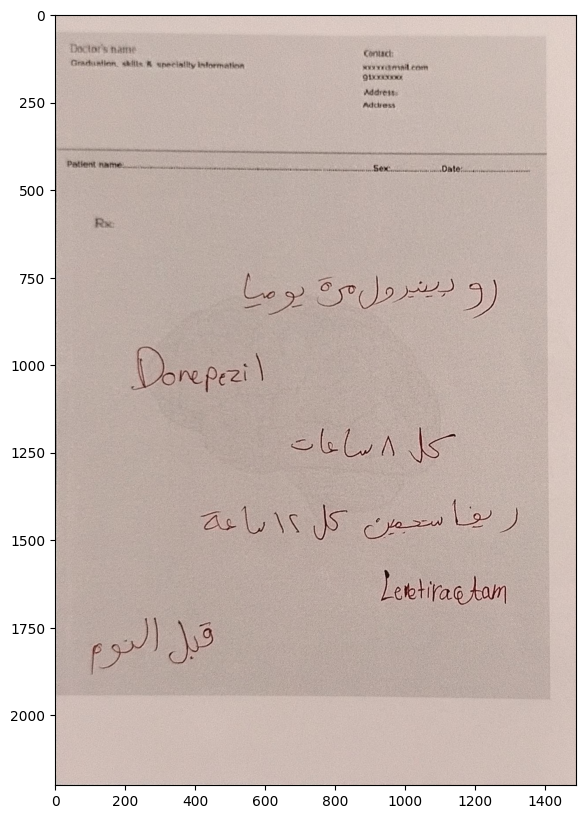

In [ ]:
# مسار الفولدر اللي فيه الصور
folder = '/content/Machathon_Prescription_Digtalization_6.00/Train_Data_Phase1'

# إنشاء مصفوفة لتخزين الصور
images_array = []
counter=0
# قراءة جميع الصور في الفولدر
for filename in os.listdir(folder):
  if (counter==1):
    break
  counter+=1

  img_path = os.path.join(folder, filename)
  if os.path.isfile(img_path):  # التأكد من أنه ملف وليس مجلد
      img = cv2.imread(img_path)  # قراءة الصورة
      if img is not None:
          images_array.append(img)  # تخزين الصورة في المصفوفة

# تحويل المصفوفة إلى NumPy array
images_array = np.array(images_array)

# طباعة عدد الصور وأبعاد أول صورة للتحقق
print(f"عدد الصور: {len(images_array)}")
print(f"أبعاد أول صورة: {images_array[0].shape if len(images_array) > 0 else 'No images found'}")
plt.figure(figsize=(10, 10))
plt.imshow(images_array[0])

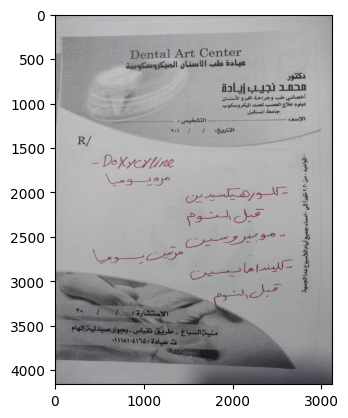

In [ ]:
source = '/content/drive/MyDrive/Machathon_Prescription_Digtalization_6.00/Train_Data_Phase1/Dental_prescription_599.jpg'
img = cv2.imread(source)
image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img)

#Used functions

In [ ]:
def adap_thresh(image, size=21, c=16):
  size = 21
  c = size - 5
  return cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, size, c)

In [ ]:
def remove_shadow(img):
  im = cv2.dilate(img, np.ones((3, 3), dtype=np.uint8), iterations=1)
  im = cv2.erode(im, np.ones((3, 3), dtype=np.uint8), iterations=1)
  return cv2.medianBlur(im, 3)

In [ ]:
def get_bounding(thresh_image, original):
  # report = []
  # ROI_number = 0
  cnts = cv2.findContours( thresh_image , cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
  cnts = cnts[0] if len(cnts) == 2 else cnts[1]
  cnts=sorted(cnts, key=lambda x: cv2.boundingRect(x)[1])
  ROI = []
  for c in cnts:
      x,y,w,h = cv2.boundingRect(c)
      if  w<thresh_image.shape[0]/2 and h<thresh_image.shape[1]/2:
          cv2.rectangle(original, (x, y), (x + w, y + h), (36,255,12), 2)
          ROI.append(thresh_image[y:y + h, x:x + w])
          # report.append(pytesseract.image_to_data(ROI,lang='eng+ara', output_type=Output.DICT))
          # print(pytesseract.image_to_string(ROI, lang='eng+ara'))
          # ROI_number += 1
          # print("ROI shape:", ROI.shape)
  return original, ROI

In [ ]:
def is_arabic(text):
    return any("\u0600" <= char <= "\u06FF" for char in text)

#give an image with tesseract result
def tesser_OCR_result(img, data):
  im = img.copy()
  #get coordinates for the words
  for i in range(0, len(data['text'])):
    #set confidence threshold for accepted words
    if data['conf'][i] < 60: continue

    #get the text and its boundaries
    x = data['left'][i]
    y = data['top'][i]
    w = data['width'][i]
    h = data['height'][i]
    text = data['text'][i]

    #draw the boundaries
    cv2.rectangle(im, (x, y), (x+w, y+h), (0, 0, 255), 2)

    #add arabic text
    if is_arabic(text):
      print(text)
      reshaped_text = arabic_reshaper.reshape(text)  # Fix isolated letters
      text = get_display(reshaped_text)  # Convert to right-to-left
    cv2.putText(im, text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 2, cv2.LINE_AA)
  plt.figure(figsize=(10, 10))
  plt.imshow(im, cmap = 'gray')
  plt.show()

In [ ]:
def sharpen_image(image):
    """Apply sharpening filter to enhance image details."""
    # Define a sharpening kernel
    sharpening_kernel = np.array([[-1, -1, -1],
                                  [-1,  9, -1],
                                  [-1, -1, -1]])

    # Apply the sharpening filter
    sharpened = cv2.filter2D(image, -1, sharpening_kernel)

    return sharpened

In [ ]:
edges = cv2.Canny(img_mean, 50, 200, apertureSize=3)
minLength = min(img_mean.shape[0],img_mean.shape[1])
lines = cv2.HoughLinesP(edges, 2, np.pi / 180, threshold=int(minLength/10), minLineLength=int(minLength/4), maxLineGap=int(minLength/4))

# Create a mask to remove lines
mask = np.ones_like(img_mean) * 255

# Draw detected lines on the mask
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(mask, (x1, y1), (x2, y2), (0, 0, 0), 2)  # Draw black lines on the mask

# Inpaint the lines using the mask
cleaned_image = cv2.inpaint(img_mean, 255 - mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
plt.figure(figsize=(10, 10))
plt.imshow(cleaned_image, cmap = 'gray')
plt.show()

NameError: name 'img_mean' is not defined

#Preprocessing

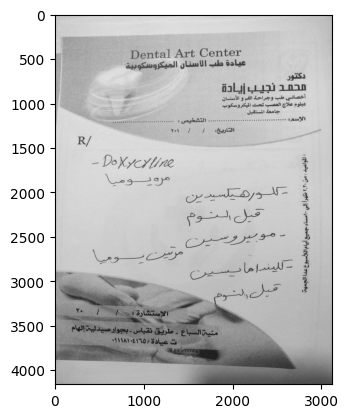

In [ ]:
plt.imshow(image, cmap = 'gray')

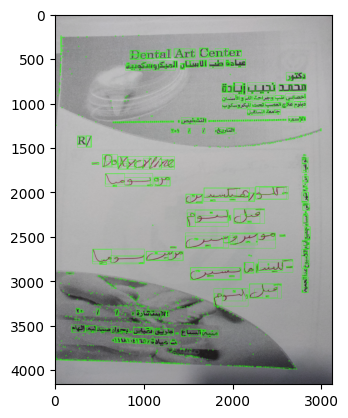

In [ ]:
thresh = adap_thresh(image)
refined_image = remove_shadow(thresh)
im, ROI = get_bounding(refined_image, img)
plt.imshow(im)
plt.show()
print(pytesseract.image_to_string(im, lang='eng+ara'))

In [ ]:
len(ROI)

5

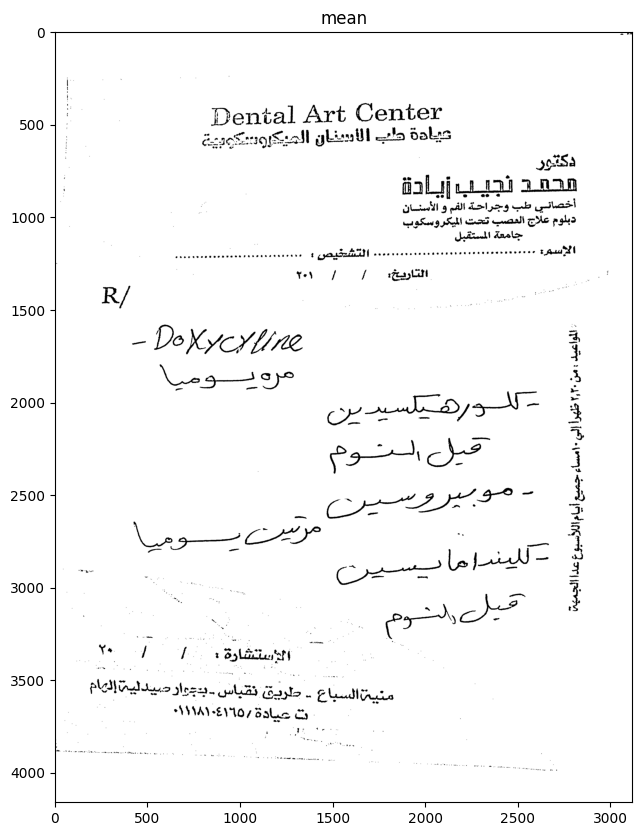

In [ ]:

if ROI == None:
  print("no ROI")
else:

  plt.figure(figsize=(10, 10))
  plt.imshow(ROI[0], cmap = 'gray')
  plt.show()

Number of Contours found = 4996


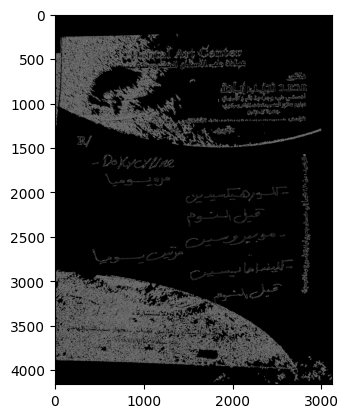

In [ ]:

edged = cv2.Canny(image, 30, 200)


# Finding Contours
# Use a copy of the image e.g. edged.copy()
# since findContours alters the image
contours, hierarchy = cv2.findContours(edged,
    cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

plt.imshow( edged , cmap='gray')


print("Number of Contours found = " + str(len(contours)))

# Draw all contours
# -1 signifies drawing all contours



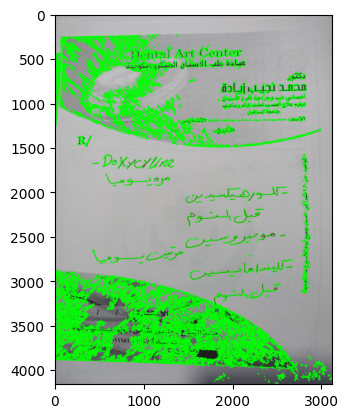

In [ ]:
original=img.copy()
cv2.drawContours(original, contours, -1, (0, 255, 0), 3)
plt.imshow(original)
plt.show()

In [ ]:
custom_config = r'--oem 2 --psm 1'

In [ ]:
output, roi = get_bounding(img_mean)
for out in output:
  tesser_OCR_result(roi, out)

NameError: name 'img_mean' is not defined

In [ ]:
data = pytesseract.image_to_data(cleaned_image,lang='eng+ara', output_type=Output.DICT)

In [ ]:
tesser_OCR_result(cleaned_image, data)

In [ ]:
!pip install easyocr

  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Using cached pyclipper-1.3.0.post6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.0 kB)
  Using cached ninja-1.11.1.3-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.3 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6

In [ ]:
reader = easyocr.Reader(['ar', 'en'], gpu=True)

NameError: name 'easyocr' is not defined

In [ ]:
results = reader.readtext(cleaned_image)
results

NameError: name 'reader' is not defined

In [ ]:
def easy_ocr_result(image, data):
  img = image.copy()
  for result in data:
    conf = result[2]
    if conf < 0.6:
      continue
    point1 = tuple(map(int, result[0][0]))
    point2 = tuple(map(int, result[0][2]))
    cv2.rectangle(img, point1, point2, (0, 0, 255), 2)

    cv2.putText(img, result[1], (point1[0], point1[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 2, cv2.LINE_AA)
    if is_arabic(result[1]):
      print(result[1])
  plt.figure(figsize=(10, 10))
  plt.imshow(img, cmap = 'gray')
  plt.show()

In [ ]:
output, roi = get_bounding(img_mean)
for out in output:
  easy_ocr_result(roi, out)

NameError: name 'img_mean' is not defined

In [ ]:
results

In [ ]:
def threshold_image(image, threshold_value=150):
    """Convert image to grayscale (if not already) and apply binary thresholding."""

    # Check if the image is already grayscale (single channel)
    if len(image.shape) == 3:
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image  # It's already grayscale

    # Apply binary thresholding
   # _, thresh = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

    return gray
img=threshold_image(img)
plt.imshow(img, cmap="gray")

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
dataset = image_dataset_from_directory(
    '/content/Machathon_Prescription_Digtalization_6.00/Train_Data_Phase1',
    labels=None,
    batch_size=32,
    image_size=(2000, 2000),
    shuffle=False,
    color_mode='grayscale',
    seed=42
)

In [ ]:
for batch in dataset.take(1):  # Take the first batch
    first_image = batch[0].numpy()  # Extract the first image and convert to NumPy array
plt.figure(figsize=(10, 10))
plt.imshow(first_image, cmap='gray')

In [ ]:
!sudo apt install tesseract-ocr
!pip install pytesseract
!apt-get install tesseract-ocr-ara


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import cv2
import pytesseract

# Load the dataset
dataset = image_dataset_from_directory(
    '/content/Machathon_Prescription_Digtalization_6.00/Train_Data_Phase1',
    labels=None,
    batch_size=32,
    image_size=(4000, 4000),
    shuffle=False,
    color_mode='grayscale',
    seed=42
)

# Extract the first image from the dataset
for batch in dataset.take(1):  # Take the first batch
    first_image = batch[0].numpy()  # Extract the first image and convert to NumPy array

# Display the original grayscale image
plt.figure(figsize=(10, 10))
plt.imshow(first_image, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

# Convert the image to a binary image using a threshold
_, binary_image = cv2.threshold(first_image, 127, 255, cv2.THRESH_BINARY)

# Display the binary image
plt.figure(figsize=(10, 10))
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Image (Threshold Applied)")
plt.axis('off')
plt.show()

# Use Tesseract to extract text from the binary image
text = pytesseract.image_to_string(binary_image, lang='ara')  # Use 'ara' for Arabic text

# Print the extracted text
print("Extracted Text:")
print(text)

In [ ]:
def gaussian_blur_image(image, kernel_size=(5, 5), sigma_x=0):
    """Apply Gaussian blur to an image to reduce noise and smooth it.

    Parameters:
    - image: Input image
    - kernel_size: Size of the Gaussian kernel (must be odd, e.g., (3,3), (5,5))
    - sigma_x: Standard deviation in the X direction (0 lets OpenCV decide)

    Returns:
    - Blurred image
    """
    blurred = cv2.GaussianBlur(image, kernel_size, sigma_x)
    return blurred
img=gaussian_blur_image(img)
plt.imshow(img,cmap='gray')

In [ ]:
# Use pytesseract to extract text from the original image
norm=erode(img,3)
norm=dilate(norm,5)
#norm=cv2.adaptiveThreshold(norm,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,5,11)
plt.imshow(norm, cmap='gray')
plt.title('Thresholded Image')
text = pytesseract.image_to_string(norm,lang='eng+ara')
print("Extracted Text:")
print(text)

In [ ]:
original = img.copy()
thresh = cv2.threshold(original, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Find contours, obtain bounding box, extract and save ROI
ROI_number = 0
cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    x,y,w,h = cv2.boundingRect(c)
    cv2.rectangle(image, (x, y), (x + w, y + h), (36,255,12), 2)
    ROI = original[y:y+h, x:x+w]
    cv2.imwrite('ROI_{}.png'.format(ROI_number), ROI)
    ROI_number += 1

cv2.imshow('image', image)
cv2.waitKey()

In [ ]:
class model:
  images=[]
  _init__(self, links):
    preprocess(self):
    model(self):
    postprocess(self):

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Add Import required libraries for your solution
import os
import cv2
import numpy as np
#from PIL import Image
#import pytesseract
import torch
import torchvision.transforms as transforms
from transformers import AutoModelForSequenceClassification, AutoTokenizer

#  Load Your Model
# --------------------------------------------------------------
# In this section, load your pre-trained model.
#
# Option 1: Load a model from Hugging Face Hub
# Ensure the model repository is public or that you have the required access token.
# MODEL_NAME = "username/model_name"
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
#
# Important: If using Hugging Face, ensure that:
# - The model repository is set to "public" or you have an authentication token.
# - The model link is accessible and does not require special permissions.
#
# Option 2: Load model weights from a local or cloud storage (e.g., Google Drive)
# If using PyTorch, ensure the model architecture is defined before loading weights.
# weights_path = "https://drive.google.com/uc?id=YOUR_FILE_ID"
#
# Ensure the Google Drive link is publicly accessible (Anyone with the link can view).

# Load the weights into the model (example in pytorch ):
# model.load_state_dict(torch.load("model.pth", map_location=torch.device('cpu')))
# model.eval()  # Set the model to evaluation mode

#%%
# Submit Function
# --------------------------------------------------------------
# This function takes a list of image paths as input and returns the extracted
# prescription text associated with each image.
#
# Args:
# images (list of str): List of paths to input images.
#
# Returns:
# list of str: Extracted prescription texts corresponding to each input image.
# --------------------------------------------------------------

def submit(images):
    """
    Processes a list of prescription images and extracts the associated text.

    Args:
        images (list of str): List of file paths to input prescription images.

    Returns:
        list of str: Extracted prescription texts corresponding to each input image.
    """
    extracted_texts = []

    for image_path in images:
        # Load and preprocess the image

        # Perform model inference


        extracted_texts.append(extracted_text)

    return extracted_texts


In [ ]:
import pandas as pd


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/EEGdata.csv")

In [ ]:
df.head()

,Time,FZ,C3,CZ,C4,PZ,PO7,OZ,PO8,AccX,AccY,AccZ,Gyro1,Gyro2,Gyro3,Battery,Counter,Validation
0,1.678707e+06,316357.21875,322398.81250,394608.53125,389349.62500,322922.56250,305854.03125,303053.37500,322677.65625,0.025391,0.962646,-0.199219,2.105713,-1.586914,0.152588,93.333344,225192.0,1.0
1,1.678707e+06,317250.93750,323556.34375,396107.81250,390746.87500,323893.15625,307837.28125,303820.93750,324047.65625,0.027588,0.966797,-0.196777,2.105713,-1.586914,0.152588,93.333344,225193.0,1.0
2,1.678707e+06,318056.40625,324850.00000,399840.43750,392210.71875,325977.78125,310939.59375,304957.18750,326281.93750,0.027344,0.968750,-0.194580,1.861572,-1.525879,0.091553,93.333344,225194.0,1.0
3,1.678707e+06,317671.59375,324489.93750,400594.25000,391721.65625,326268.25000,310837.59375,304883.96875,326278.43750,0.024658,0.969482,-0.194092,1.770019,-1.586914,0.122070,93.333344,225195.0,1.0
4,1.678707e+06,316649.50000,323027.96875,397473.59375,390003.71875,324449.25000,307816.15625,303751.62500,324125.78125,0.023926,0.961914,-0.199463,1.647949,-1.556396,0.183105,93.333344,225196.0,1.0
